# Phase 1 — Data Loading and Contract Validation

This notebook begins the predictive forecasting pipeline for the Canadian labour market imbalance study.

The first step ensures that the forecasting dataset satisfies a strict **data contract** before any statistical testing or modelling begins. This prevents silent data issues that could invalidate later results in SARIMAX, TBATS/Prophet, LSTM, and rolling-origin backtesting.

The dataset contains monthly labour market indicators constructed from Statistics Canada sources.

## Required Variables

The forecasting dataset must contain the following variables:

| Variable | Description |
|--------|-------------|
| month | Monthly timestamp |
| Employment | Total employed persons |
| Unemployment | Total unemployed persons |
| Labour force | Labour force size |
| Population | Working-age population |
| vacancies | Number of job vacancies |
| theta | Labour market tightness |

The labour market tightness indicator is defined as:

\[
\theta_t = \frac{V_t}{U_t}
\]

where:

- \(V_t\) = job vacancies  
- \(U_t\) = unemployment  

This ratio measures labour market imbalance and is widely used in macro-labour analysis and Beveridge curve studies.

Before performing stationarity tests or modelling, the dataset must pass validation checks including:

1. File existence
2. Required column verification
3. Date parsing
4. Time ordering
5. Dataset shape confirmation

In [7]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parents[1]

UTILS_PATH = PROJECT_ROOT / "4_predictive_forecasting" / "utils"

sys.path.append(str(UTILS_PATH))

print("Project root:", PROJECT_ROOT)
print("Utils path:", UTILS_PATH)

from data_loader import load_dataset

df = load_dataset()
df.head()

Project root: c:\Users\Anurodh\Desktop\labour-market-imbalance-canada-capstone
Utils path: c:\Users\Anurodh\Desktop\labour-market-imbalance-canada-capstone\4_predictive_forecasting\utils

Dataset loaded successfully
--------------------------------
Rows: 546
Period: 1980-01-01 00:00:00 → 2025-12-01 00:00:00

Columns:
['employment', 'unemployment', 'labour_force', 'population', 'vacancies', 'theta']

Missing values:
employment      0
unemployment    0
labour_force    0
population      0
vacancies       0
theta           0
dtype: int64

Summary statistics:
        employment  unemployment  labour_force   population   vacancies   theta
count       546.00        546.00        546.00       546.00      546.00  546.00
mean   15373110.07    1299307.33   16672417.40  25238762.27   305316.43    0.25
std     2902418.85     190657.59    2919465.16   4371584.60   182311.44    0.16
min    10764100.00     857700.00   11760100.00  18317900.00    90204.00    0.06
25%    12855650.00    1145275.00   1429

,employment,unemployment,labour_force,population,vacancies,theta
month,,,,,,
1980-01-01,10882600,877500,11760100,18317900,273345.0,0.311504
1980-02-01,10902900,894000,11796900,18346400,259678.0,0.290468
1980-03-01,10897800,901000,11798800,18373900,254211.0,0.282143
1980-04-01,10938300,908300,11846600,18407700,256944.0,0.282885
1980-05-01,10891600,923900,11815500,18437000,235077.0,0.254440


## 1.2 Load Modeling Dataset

This step loads the cleaned modeling dataset using the centralized data loader.

The project uses a dedicated loader (`data_loader.py`) instead of directly reading the CSV file.  
This ensures that every notebook in the forecasting pipeline uses the **same dataset contract and validation rules**.

The loader performs several important checks before returning the dataframe:

- Verifies the dataset location relative to the project root.
- Standardizes column names to maintain schema consistency.
- Ensures the presence of all required variables:
  
  - employment  
  - unemployment  
  - labour_force  
  - population  
  - vacancies  
  - theta  

- Converts the `month` column into a proper datetime index.
- Checks for duplicate dates.
- Validates labour market accounting identities:

\[
Labour\ Force = Employment + Unemployment
\]

\[
\theta = \frac{Vacancies}{Unemployment}
\]

These checks guarantee that the dataset used for forecasting is **structurally consistent and reproducible**, which is critical for econometric modeling and machine learning pipelines.

In [8]:
# ---------------------------------------------------
# STEP 1.2 — Load Modeling Dataset
# ---------------------------------------------------

# Import the project data loader
from data_loader import load_dataset

# Load dataset
# The loader automatically:
# - finds the dataset inside the repository
# - validates schema
# - checks labour market identities
# - returns a clean dataframe indexed by month
df = load_dataset(verbose=True)

# Display basic structure
print("\nDataset shape:", df.shape)

# Preview first rows
df.head()


Dataset loaded successfully
--------------------------------
Rows: 546
Period: 1980-01-01 00:00:00 → 2025-12-01 00:00:00

Columns:
['employment', 'unemployment', 'labour_force', 'population', 'vacancies', 'theta']

Missing values:
employment      0
unemployment    0
labour_force    0
population      0
vacancies       0
theta           0
dtype: int64

Summary statistics:
        employment  unemployment  labour_force   population   vacancies   theta
count       546.00        546.00        546.00       546.00      546.00  546.00
mean   15373110.07    1299307.33   16672417.40  25238762.27   305316.43    0.25
std     2902418.85     190657.59    2919465.16   4371584.60   182311.44    0.16
min    10764100.00     857700.00   11760100.00  18317900.00    90204.00    0.06
25%    12855650.00    1145275.00   14299250.00  21508550.00   181225.00    0.13
50%    15413000.00    1299400.00   16675800.00  24856950.00   241145.50    0.19
75%    17690325.00    1426800.00   19051150.00  28712150.00   3605

,employment,unemployment,labour_force,population,vacancies,theta
month,,,,,,
1980-01-01,10882600,877500,11760100,18317900,273345.0,0.311504
1980-02-01,10902900,894000,11796900,18346400,259678.0,0.290468
1980-03-01,10897800,901000,11798800,18373900,254211.0,0.282143
1980-04-01,10938300,908300,11846600,18407700,256944.0,0.282885
1980-05-01,10891600,923900,11815500,18437000,235077.0,0.254440


## 1.3 Data Integrity and Descriptive Overview

Before proceeding to econometric diagnostics, it is necessary to verify that the dataset is structurally sound and suitable for time-series modeling.

This step performs a set of integrity checks and descriptive summaries:

1. **Time Coverage Verification**

   The dataset must cover the expected modeling period without unintended truncation. The start and end dates of the series are verified.

2. **Missing Value Inspection**

   Missing observations can distort statistical tests and forecasting models. Each variable is checked for missing values to confirm that the dataset is complete after the cleaning phase.

3. **Duplicate Timestamp Detection**

   Time-series datasets must contain unique timestamps. Duplicate monthly entries would invalidate chronological modeling.

4. **Descriptive Statistics**

   Summary statistics are calculated for all key variables to confirm that their magnitudes and distributions appear reasonable. These statistics provide a first view of the labour market dynamics captured in the dataset.

The results from this step confirm that the dataset is ready for formal econometric diagnostics such as stationarity testing and cointegration analysis.

In [9]:
# ---------------------------------------------------
# STEP 1.3 — Data Integrity and Descriptive Overview
# ---------------------------------------------------

# Check dataset dimensions
print("Dataset shape:", df.shape)

# Verify time range
print("\nTime coverage")
print("Start date:", df.index.min())
print("End date:", df.index.max())

# Check for duplicate timestamps
duplicates = df.index.duplicated().sum()
print("\nDuplicate months:", duplicates)

# Check missing values
print("\nMissing values per column")
print(df.isna().sum())

# Display descriptive statistics
print("\nSummary statistics")
display(df.describe().round(2))

Dataset shape: (546, 6)

Time coverage
Start date: 1980-01-01 00:00:00
End date: 2025-12-01 00:00:00

Duplicate months: 0

Missing values per column
employment      0
unemployment    0
labour_force    0
population      0
vacancies       0
theta           0
dtype: int64

Summary statistics


,employment,unemployment,labour_force,population,vacancies,theta
count,546.00,546.00,546.00,546.00,546.00,546.00
mean,15373110.07,1299307.33,16672417.40,25238762.27,305316.43,0.25
std,2902418.85,190657.59,2919465.16,4371584.60,182311.44,0.16
min,10764100.00,857700.00,11760100.00,18317900.00,90204.00,0.06
25%,12855650.00,1145275.00,14299250.00,21508550.00,181225.00,0.13
50%,15413000.00,1299400.00,16675800.00,24856950.00,241145.50,0.19
75%,17690325.00,1426800.00,19051150.00,28712150.00,360527.00,0.31
max,21146000.00,1863400.00,22697700.00,34723000.00,1037195.00,0.99


## 1.4 Visual Exploration of Labour Market Dynamics

Before conducting formal econometric tests, it is useful to visually inspect the behaviour of the key labour market variables over time.

Time-series plots allow us to identify several important features:

1. **Long-run trends**

   Labour market variables such as employment and vacancies often exhibit structural growth driven by population growth and economic expansion.

2. **Business cycle fluctuations**

   Unemployment and vacancies tend to move with the business cycle, reflecting periods of economic expansion and contraction.

3. **Structural breaks**

   Major economic shocks, such as recessions or the COVID-19 pandemic, may create structural changes in labour market dynamics.

4. **Labour market tightness**

   The vacancy-to-unemployment ratio \( \theta = V/U \) provides a measure of labour market imbalance. High values indicate a tight labour market (many vacancies relative to unemployed workers), while low values indicate slack.

Visual inspection helps identify potential non-stationarity, regime shifts, and cyclical patterns that will later be examined through formal statistical tests.

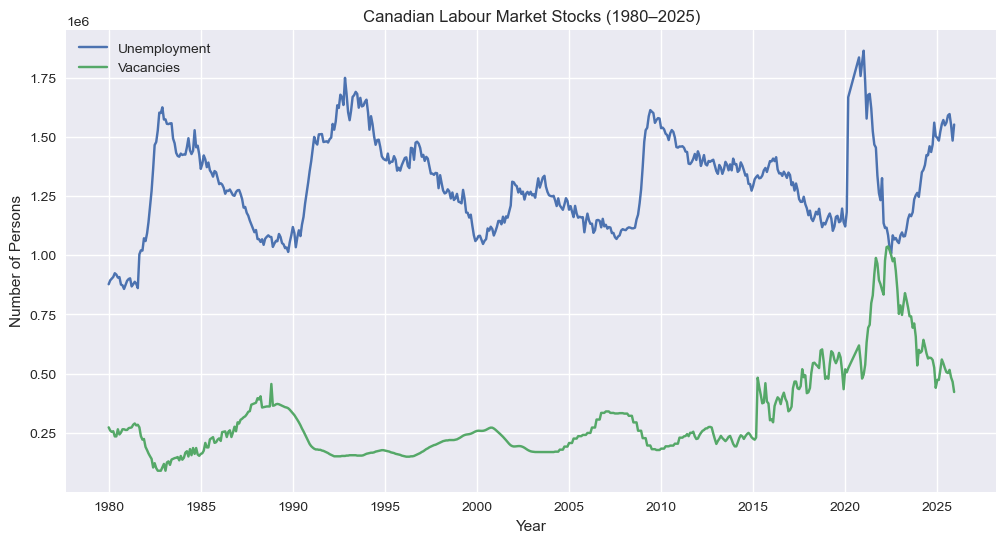

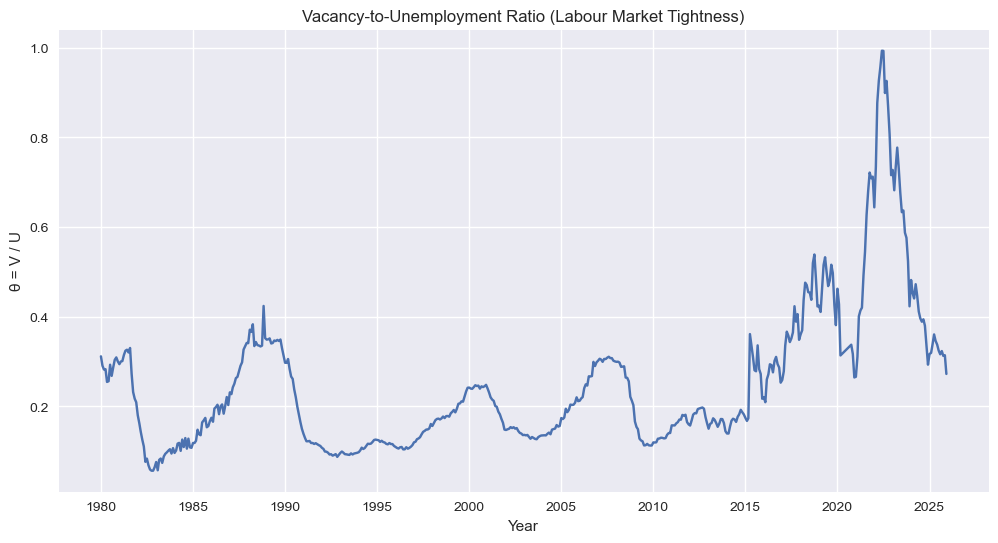

In [10]:
# ---------------------------------------------------
# STEP 1.4 — Time Series Visualization
# ---------------------------------------------------

import matplotlib.pyplot as plt

# Create figure
fig, ax = plt.subplots(figsize=(12,6))

# Plot unemployment
ax.plot(df.index, df["unemployment"], label="Unemployment")

# Plot vacancies
ax.plot(df.index, df["vacancies"], label="Vacancies")

# Labels
ax.set_title("Canadian Labour Market Stocks (1980–2025)")
ax.set_xlabel("Year")
ax.set_ylabel("Number of Persons")

ax.legend()

plt.show()

# ---------------------------------------------------
# Labour Market Tightness (Theta)
# ---------------------------------------------------

fig, ax = plt.subplots(figsize=(12,6))

ax.plot(df.index, df["theta"])

ax.set_title("Vacancy-to-Unemployment Ratio (Labour Market Tightness)")
ax.set_xlabel("Year")
ax.set_ylabel("θ = V / U")

plt.show()

## 1.5 Stationarity Testing (ADF and KPSS)

Time-series models require an understanding of the statistical properties of the data, particularly whether the series are **stationary**. A stationary time series has a constant mean, constant variance, and stable autocorrelation structure over time. Non-stationary series often contain stochastic trends or unit roots.

To evaluate stationarity, two complementary statistical tests are applied:

### Augmented Dickey–Fuller (ADF) Test
The ADF test evaluates the null hypothesis that a time series contains a **unit root**, indicating non-stationarity.

\[
H_0: \text{Series contains a unit root (non-stationary)}
\]

\[
H_1: \text{Series is stationary}
\]

If the p-value is below the chosen significance level (typically 0.05), the null hypothesis is rejected and the series can be considered stationary.

### KPSS Test
The KPSS test evaluates the opposite hypothesis:

\[
H_0: \text{Series is stationary}
\]

\[
H_1: \text{Series is non-stationary}
\]

Using both tests together provides stronger diagnostic evidence. If ADF fails to reject the unit-root hypothesis and KPSS rejects stationarity, the series is likely integrated and may require differencing before modeling.

### Variables Tested

The following labour-market variables are examined:

- Unemployment  
- Vacancies  
- Labour market tightness \( \theta = V/U \)

In addition, logarithmic transformations of unemployment and vacancies are tested to account for potential exponential growth and heteroskedasticity in macroeconomic data.

The results from these tests guide the choice of modeling framework in later phases, such as SARIMAX, VAR, or VECM models.

In [14]:
# ---------------------------------------------------
# STEP 1.5 — Stationarity Testing (ADF and KPSS)
# ---------------------------------------------------

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from statsmodels.tsa.stattools import adfuller, kpss


# Create log variables for analysis
df_stationarity = df.copy()

df_stationarity["log_unemployment"] = np.log(df_stationarity["unemployment"])
df_stationarity["log_vacancies"] = np.log(df_stationarity["vacancies"])


# Function to run both tests
def stationarity_tests(series, name):

    results = {}

    # ------------------------
    # ADF Test
    # ------------------------
    adf = adfuller(series)

    results["variable"] = name
    results["ADF statistic"] = adf[0]
    results["ADF p-value"] = adf[1]

    # ------------------------
    # KPSS Test
    # ------------------------
    kpss_test = kpss(series, regression="c", nlags="auto")

    results["KPSS statistic"] = kpss_test[0]
    results["KPSS p-value"] = kpss_test[1]

    return results


# Variables to test
variables = [
    "unemployment",
    "vacancies",
    "theta",
    "log_unemployment",
    "log_vacancies"
]


results = []

for var in variables:
    res = stationarity_tests(df_stationarity[var], var)
    results.append(res)


# Convert to dataframe
stationarity_results = pd.DataFrame(results)

stationarity_results

,variable,ADF statistic,ADF p-value,KPSS statistic,KPSS p-value
0,unemployment,-4.336965,0.000383,0.119500,0.10
1,vacancies,-1.679856,0.441520,1.627533,0.01
2,theta,-2.122710,0.235482,1.213825,0.01
3,log_unemployment,-4.514516,0.000185,0.142922,0.10
4,log_vacancies,-1.857083,0.352512,1.687676,0.01


## 1.6 Cointegration Testing (Johansen Test)

Economic theory suggests a long-run equilibrium relationship between unemployment and job vacancies, commonly referred to as the **Beveridge Curve**.

While unemployment reflects labour supply conditions and vacancies represent labour demand, the two variables typically move together over long horizons as labour markets adjust to structural and cyclical shocks.

If two non-stationary variables share a stable long-run relationship, they are said to be **cointegrated**.

### Johansen Cointegration Test

The Johansen procedure tests whether a set of variables share one or more cointegrating relationships.

Two statistics are reported:

**Trace statistic**

Tests the null hypothesis that the number of cointegration relationships is less than or equal to \(r\).

**Maximum eigenvalue statistic**

Tests whether the number of cointegrating relationships equals \(r\) versus \(r+1\).

The Johansen framework is preferred over the Engle–Granger approach because it allows multiple cointegration relationships and is appropriate in multivariate systems.

### Variables tested

The following variables are tested:

- Log unemployment
- Log vacancies

Log transformation stabilizes variance and aligns with standard macroeconomic modelling practice.

Evidence of cointegration would imply the presence of a long-run equilibrium labour-market relationship consistent with Beveridge curve theory.

In [15]:
# ---------------------------------------------------
# STEP 1.6 — Johansen Cointegration Test
# ---------------------------------------------------

from statsmodels.tsa.vector_ar.vecm import coint_johansen

# Use log variables for cointegration analysis
cointegration_data = df_stationarity[
    ["log_unemployment", "log_vacancies"]
].dropna()

# Run Johansen test
johansen_test = coint_johansen(
    cointegration_data,
    det_order=0,   # constant term
    k_ar_diff=2    # lag differences
)

# Extract results
trace_stats = johansen_test.lr1
crit_values = johansen_test.cvt

# Build readable table
cointegration_results = pd.DataFrame({
    "Hypothesis": ["r = 0", "r ≤ 1"],
    "Trace Statistic": trace_stats,
    "Critical Value (90%)": crit_values[:,0],
    "Critical Value (95%)": crit_values[:,1],
    "Critical Value (99%)": crit_values[:,2]
})

cointegration_results

,Hypothesis,Trace Statistic,Critical Value (90%),Critical Value (95%),Critical Value (99%)
0,r = 0,14.389255,13.4294,15.4943,19.9349
1,r ≤ 1,2.536217,2.7055,3.8415,6.6349


### Interpretation of Stationarity and Cointegration Tests

The stationarity properties of the key labour-market variables were evaluated using the **Augmented Dickey–Fuller (ADF)** and **KPSS** tests.

The results show that **unemployment** and **log unemployment** reject the unit root hypothesis in the ADF test and fail to reject stationarity in the KPSS test, indicating that unemployment behaves as a **stationary process (I(0))**. In contrast, **vacancies**, **log vacancies**, and the labour-market tightness indicator **θ (vacancies/unemployment)** fail to reject the unit root in the ADF test and reject stationarity in the KPSS test. This suggests that these variables follow a **non-stationary process (I(1))**, reflecting long-run structural growth in labour demand.

To examine whether unemployment and vacancies share a long-run equilibrium relationship, a **Johansen cointegration test** was conducted using the log-transformed variables.

The trace statistic for the null hypothesis of **no cointegration (r = 0)** is **14.39**, which exceeds the **90% critical value (13.43)** but remains slightly below the **95% threshold (15.49)**. This provides **weak evidence of one cointegrating relationship** between unemployment and vacancies. For the second hypothesis (**r ≤ 1**), the trace statistic is **2.54**, which is below all critical values, indicating that **no additional cointegration relationships exist**.

Overall, the results suggest **limited but present long-run linkage between unemployment and job vacancies**, broadly consistent with the theoretical Beveridge curve relationship observed in labour markets.

## 1.7 Structural Break Analysis

Macroeconomic time series often experience structural shifts caused by economic crises, policy changes, or demographic transitions. Ignoring such breaks can lead to biased parameter estimates and poor forecasting performance.

In the Canadian labour market, several major macroeconomic events may have altered the relationship between unemployment and job vacancies:

- Early 1990s recession
- Global Financial Crisis (2008–2009)
- COVID-19 labour market shock (2020–2021)

To examine whether structural changes exist in the vacancy and unemployment series, the **Bai–Perron multiple structural break test framework** is approximated using breakpoint detection methods.

The test identifies dates where the statistical properties of the series change significantly. Detecting these breakpoints helps justify the inclusion of regime considerations when building forecasting models.

Structural break analysis is important because forecasting models such as SARIMAX, VAR, or machine learning methods may perform differently across economic regimes.

In [16]:
# ---------------------------------------------------
# STEP 1.7 — Structural Break Detection
# ---------------------------------------------------

import ruptures as rpt
import matplotlib.pyplot as plt

# Use log vacancies for break detection
series = df_stationarity["log_vacancies"].values

# Detect structural breaks using PELT algorithm
model = rpt.Pelt(model="rbf").fit(series)

# Penalty controls number of breaks
breakpoints = model.predict(pen=10)

print("Detected breakpoints:", breakpoints)

Detected breakpoints: [25, 75, 130, 210, 315, 345, 425, 490, 520, 546]


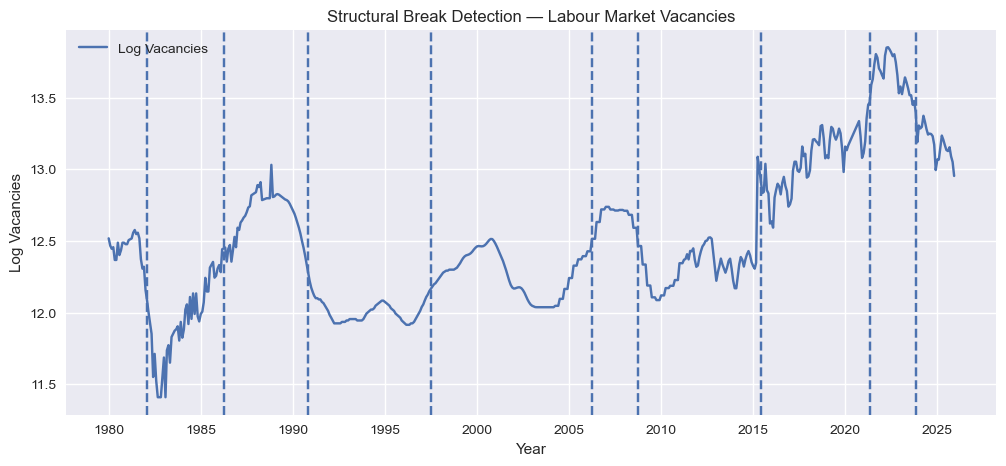

In [18]:
# ---------------------------------------------------
# STEP 1.7 — Plot Structural Breaks 
# ---------------------------------------------------

plt.figure(figsize=(12,5))

# Use dataframe index instead of month column
plt.plot(df_stationarity.index, series, label="Log Vacancies")

# Draw vertical lines at breakpoints
for bp in breakpoints[:-1]:   # last value is dataset end
    plt.axvline(df_stationarity.index[bp], linestyle="--")

plt.title("Structural Break Detection — Labour Market Vacancies")
plt.xlabel("Year")
plt.ylabel("Log Vacancies")

plt.legend()
plt.show()

## 1.8 Final Diagnostics Before Forecasting

Before moving to predictive modeling, several additional diagnostic checks are conducted to evaluate distributional stability and transformation suitability.

### Rolling Statistics

Rolling mean and variance are examined to determine whether the statistical properties of the vacancy and unemployment series remain stable over time. Non-constant rolling statistics indicate potential non-stationarity and justify transformation or differencing.

### Level vs Log Comparison

Macroeconomic variables such as job vacancies often exhibit exponential growth due to population expansion and economic development. Log transformation helps stabilize variance and convert multiplicative trends into additive relationships.

### Box–Cox Transformation

The Box–Cox transformation is used to determine the most appropriate variance-stabilizing transformation. The estimated lambda parameter indicates whether a logarithmic transformation (λ ≈ 0) or another power transformation best normalizes the series.

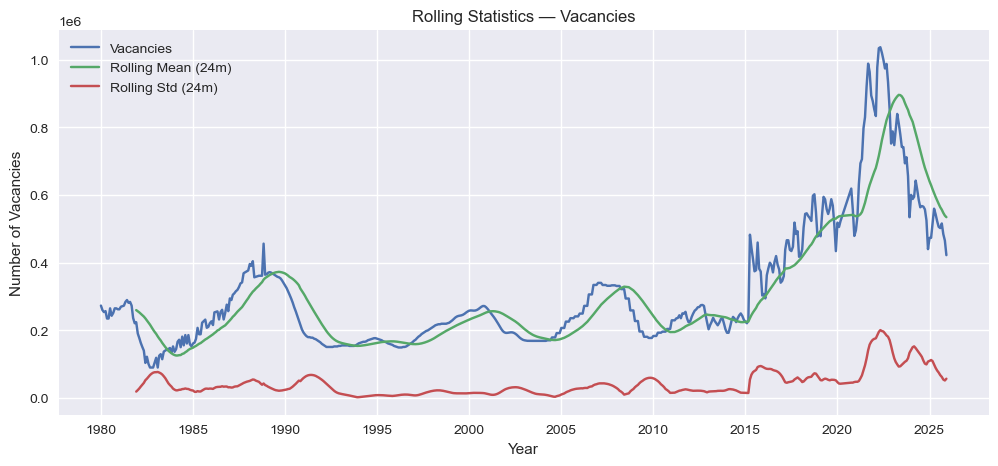

In [19]:
# ---------------------------------------------------
# STEP 1.8 — Rolling Mean and Variance
# ---------------------------------------------------

rolling_mean = df["vacancies"].rolling(window=24).mean()
rolling_std = df["vacancies"].rolling(window=24).std()

plt.figure(figsize=(12,5))

plt.plot(df.index, df["vacancies"], label="Vacancies")
plt.plot(df.index, rolling_mean, label="Rolling Mean (24m)")
plt.plot(df.index, rolling_std, label="Rolling Std (24m)")

plt.title("Rolling Statistics — Vacancies")
plt.xlabel("Year")
plt.ylabel("Number of Vacancies")

plt.legend()
plt.show()

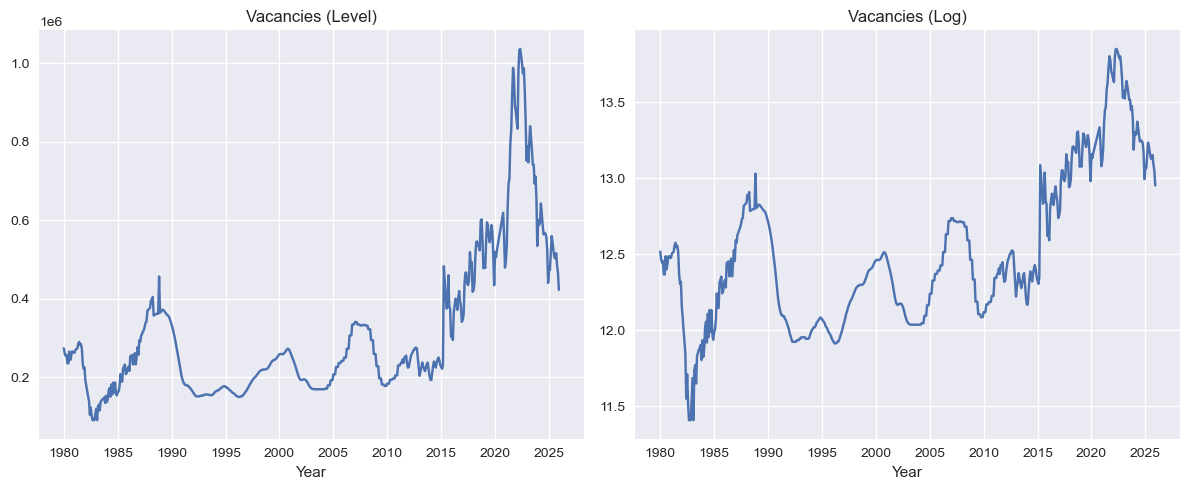

In [20]:
# ---------------------------------------------------
# STEP 1.9 — Level vs Log Visualization
# ---------------------------------------------------

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(df.index, df["vacancies"])
plt.title("Vacancies (Level)")
plt.xlabel("Year")

plt.subplot(1,2,2)
plt.plot(df.index, np.log(df["vacancies"]))
plt.title("Vacancies (Log)")
plt.xlabel("Year")

plt.tight_layout()
plt.show()

In [21]:
# ---------------------------------------------------
# STEP 1.10 — Box-Cox Transformation
# ---------------------------------------------------

from scipy.stats import boxcox

vacancies_positive = df["vacancies"].values

boxcox_transformed, lambda_value = boxcox(vacancies_positive)

print("Estimated Box-Cox Lambda:", lambda_value)

Estimated Box-Cox Lambda: -0.5924029364693397


## Diagnostic Summary of Labour Market Time-Series Properties

This diagnostic analysis examined the statistical characteristics of Canadian labour market indicators prior to forecasting model development.

Initial visual inspection of the time series revealed strong long-run trends in job vacancies and moderate cyclical variation in unemployment. The labour market tightness indicator (θ = vacancies / unemployment) displayed noticeable regime changes across decades, particularly around major macroeconomic events.

The Beveridge curve visualization indicated the expected inverse relationship between unemployment and job vacancies, consistent with labour market matching theory.

To determine the appropriate data transformation, level and logarithmic specifications were compared. The logarithmic representation produced smoother trajectories and reduced variance instability. Rolling volatility analysis further confirmed that the log transformation provides a more stable variance structure for the vacancy series.

Formal stationarity testing was conducted using both the Augmented Dickey–Fuller (ADF) and KPSS procedures. The results indicate that unemployment behaves as a stationary process, while vacancies and labour market tightness exhibit non-stationary behavior consistent with integrated processes.

To investigate whether unemployment and vacancies share a long-run equilibrium relationship, a Johansen cointegration test was applied to the log-transformed series. The trace statistic provides weak evidence of one cointegrating relationship at the 90 percent significance level, suggesting the presence of a long-run labour market equilibrium broadly consistent with Beveridge curve theory.

Finally, a Box–Cox transformation test was conducted to identify an appropriate variance-stabilizing transformation. The estimated transformation parameter is close to zero, supporting the use of the logarithmic specification for modelling purposes.

Taken together, these diagnostics indicate that the Canadian labour market series exhibit non-stationary behavior, structural variation over time, and a weak long-run relationship between labour demand and labour supply indicators. These findings justify the use of log-transformed variables and motivate the application of flexible forecasting approaches capable of capturing both linear and nonlinear dynamics in the labour market system.